In [4]:
import xarray as xr
import glob
import xrft
import matplotlib.pyplot as plt
import numpy as np
from xgcm import Grid
from datatree import open_datatree, DataTree 

In [5]:
def open_running(dir ='/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/'): 
    
    files = sorted(glob.glob(dir+'prog__*.nc'))
    files_z = sorted(glob.glob(dir+'prog_z_*.nc'))
               
    ds = xr.open_mfdataset(files[:-1], decode_times=False)
    ds_z = xr.open_mfdataset(files_z[:-1], decode_times=False)

    return ds, ds_z

In [10]:
# no sponge 

ds_ns, ds_ns_z = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_no_sponge_seamount/')
ds_ns_ann, ds_ns_ann_z = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_no_sponge_seamount_ANN_test3_long/')

In [9]:
# sponge 

ds_s, ds_s_z = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_seamount/')
ds_s_ann, ds_s_ann_z = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_seamount_ANN_test3_long/')

In [28]:
ds_ns_z

<xarray.Dataset>
Dimensions:  (xh: 88, yh: 80, z_l: 30, z_i: 31, Time: 150, xq: 89, yq: 81)
Coordinates:
  * xh       (xh) float64 0.125 0.375 0.625 0.875 ... 21.12 21.38 21.62 21.88
  * yh       (yh) float64 -49.88 -49.62 -49.38 -49.12 ... -30.62 -30.38 -30.12
  * z_l      (z_l) float64 2.5 10.0 20.0 32.5 ... 2.5e+03 3e+03 3.5e+03 4e+03
  * z_i      (z_i) float64 0.0 5.0 15.0 25.0 ... 3.25e+03 3.75e+03 4.25e+03
  * Time     (Time) float64 10.0 20.0 30.0 40.0 ... 1.48e+03 1.49e+03 1.5e+03
  * xq       (xq) float64 0.0 0.25 0.5 0.75 1.0 ... 21.0 21.25 21.5 21.75 22.0
  * yq       (yq) float64 -50.0 -49.75 -49.5 -49.25 ... -30.5 -30.25 -30.0
Data variables:
    temp     (Time, z_l, yh, xh) float32 dask.array<chunksize=(10, 30, 80, 88), meta=np.ndarray>
    umo      (Time, z_l, yh, xq) float32 dask.array<chunksize=(10, 30, 80, 89), meta=np.ndarray>
    vmo      (Time, z_l, yq, xh) float32 dask.array<chunksize=(10, 30, 81, 88), meta=np.ndarray>
    u        (Time, z_l, yh, xq) float32 dask.array<chunksize=(10, 30, 80, 89), meta=np.ndarray>
    v        (Time, z_l, yq, xh) float32 dask.array<chunksize=(10, 30, 81, 88), meta=np.ndarray>
    h        (Time, z_l, yh, xh) float64 dask.array<chunksize=(10, 30, 80, 88), meta=np.ndarray>
Attributes:
    filename:   prog_z__00010.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

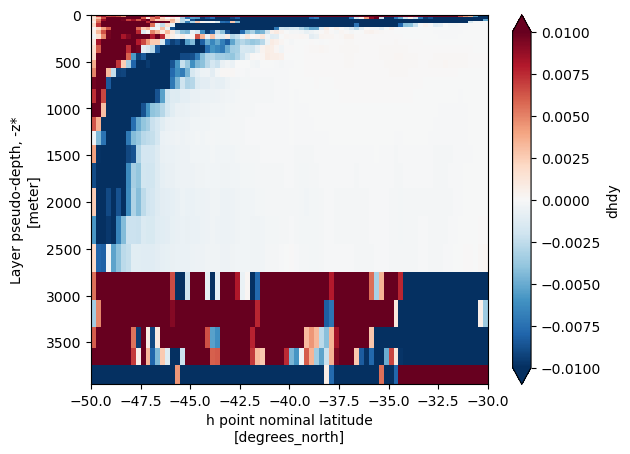

In [24]:
ds_ns_ann.dhdy.isel(Time=slice(-20, None)).mean(['xh','Time']).plot(vmin=-0.01)
plt.gca().invert_yaxis()

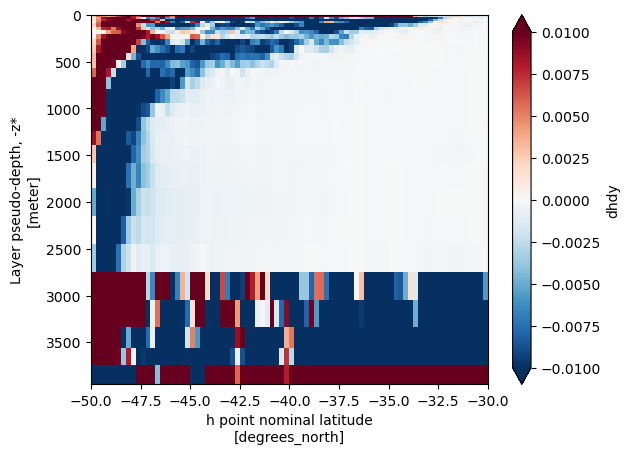

In [23]:
ds_s_ann.dhdy.isel(Time=slice(-20, None)).mean(['xh','Time']).plot(vmin=-0.01)
plt.gca().invert_yaxis()

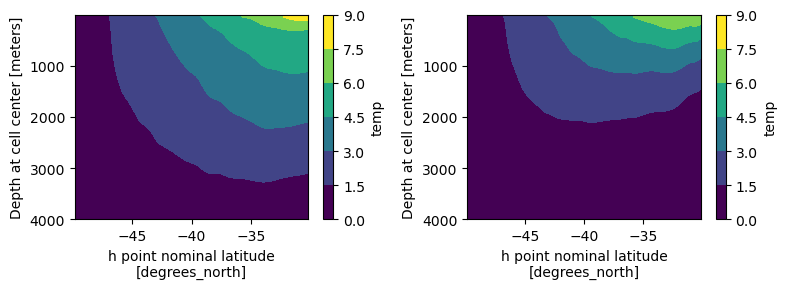

In [32]:
plt.figure(figsize=(8,3))

plt.subplot(121)
ds_ns_ann_z.temp.isel(Time=slice(-20, None)).mean(['xh','Time']).plot.contourf()
plt.gca().invert_yaxis()

plt.subplot(122)
ds_s_ann_z.temp.isel(Time=slice(-20, None)).mean(['xh','Time']).plot.contourf()
plt.gca().invert_yaxis()

plt.tight_layout()

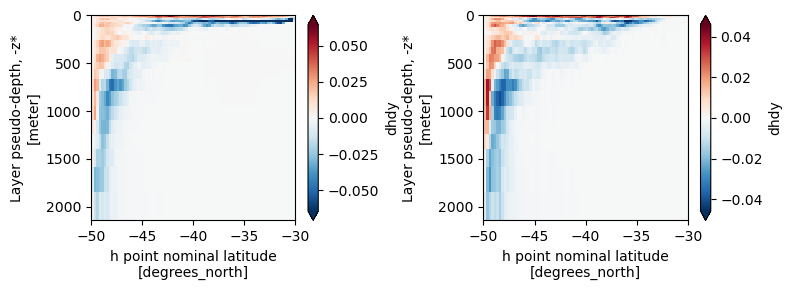

In [36]:
plt.figure(figsize=(8,3))

plt.subplot(121)
ds_ns_ann.dhdy.isel(Time=slice(-20, None)).sel(zl=slice(0, 2000)).mean(['xh','Time']).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(122)
ds_s_ann.dhdy.isel(Time=slice(-20, None)).sel(zl=slice(0, 2000)).mean(['xh','Time']).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()

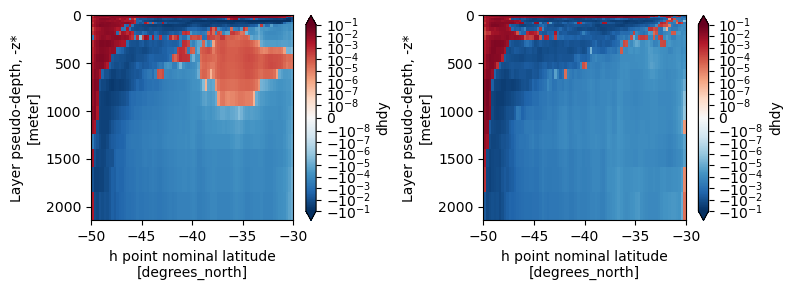

In [38]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define a symmetric log norm
vmin = -1e-1  # adjust based on your data range
vmax = 1e-1
linthresh = 1e-8  # region around zero that behaves linearly
norm = mcolors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)

plt.figure(figsize=(8, 3))

plt.subplot(121)
p1 = ds_ns_ann.dhdy.isel(Time=slice(-20, None)).sel(zl=slice(0, 2000)).mean(['xh', 'Time']).plot(
    norm=norm, cbar_kwargs={"label": "dhdy", "extend": "both"})
plt.gca().invert_yaxis()

plt.subplot(122)
p2 = ds_s_ann.dhdy.isel(Time=slice(-20, None)).sel(zl=slice(0, 2000)).mean(['xh', 'Time']).plot(
    norm=norm, cbar_kwargs={"label": "dhdy", "extend": "both"})
plt.gca().invert_yaxis()

plt.tight_layout()


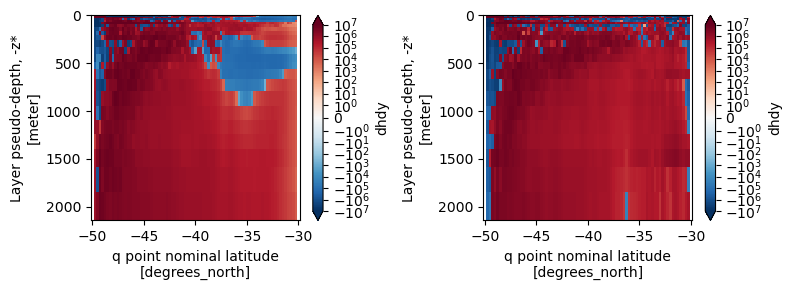

In [41]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define a symmetric log norm
vmin = -1e7  # adjust based on your data range
vmax = 1e7
linthresh = 1  # region around zero that behaves linearly
norm = mcolors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)

plt.figure(figsize=(8, 3))

plt.subplot(121)
p1 = ds_ns_ann.vhGM.isel(Time=slice(-20, None)).sel(zl=slice(0, 2000)).mean(['xh', 'Time']).plot(
    norm=norm, cbar_kwargs={"label": "dhdy", "extend": "both"})
plt.gca().invert_yaxis()

plt.subplot(122)
p2 = ds_s_ann.vhGM.isel(Time=slice(-20, None)).sel(zl=slice(0, 2000)).mean(['xh', 'Time']).plot(
    norm=norm, cbar_kwargs={"label": "dhdy", "extend": "both"})
plt.gca().invert_yaxis()

plt.tight_layout()
